In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("final_ml_dataset.csv")

# Features and labels
X = df.drop("Label", axis=1)   # or whatever label column name is
y = df["Label"]

# Split (VERY IMPORTANT: stratify for balance)



In [3]:
df = pd.read_csv("final_ml_dataset.csv")

# Remove unnamed/sample ID column explicitly
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Clean column names
df.columns = df.columns.str.strip()
df = df.select_dtypes(include=['number'])
# Split features & label
X = df.drop("Label", axis=1)
y = df["Label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
print(X.head())
print(X.dtypes)

       MMP3    SHISA3     KRT14        C7      IRX2     KRT17      SPIC  \
0 -0.709200  0.034712 -1.627333  0.032657 -0.789644 -0.022354 -0.824317   
1 -0.833507  0.737577 -0.353757  0.779482  0.943161  0.861856  0.246452   
2  1.121834 -1.372543  1.291959 -1.918531  0.718529  1.374031 -0.824317   
3 -0.148815 -1.372543 -0.413127  0.205043 -2.170038 -1.327987 -0.824317   
4  0.993687 -1.372543  0.158419 -1.307441  0.396764  0.323499 -0.824317   

       DMKN    FAM83H      MMP1  ...      EPN3    WFDC12      DLX3      EBF2  \
0 -3.197269 -3.280937  0.163263  ... -0.487946 -0.456675 -0.083875 -2.162091   
1  0.503427  1.040266 -1.643603  ...  0.312564 -0.456675  0.328059  0.150689   
2  0.611906  0.305926  1.104846  ...  1.067769  1.177994  0.707822  0.180518   
3  0.611772 -4.935175 -1.235839  ... -1.126954 -0.456675 -1.842905  0.638297   
4  0.387151  0.240685  0.749418  ...  0.485141  0.084436 -1.259906 -0.117305   

     DUOXA1      LIFR      CD1D    CAPNS2     LYPD3    SPRR2G  
0 -0

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("final_ml_dataset.csv")

# Remove unwanted index/sample ID column
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Clean column names
df.columns = df.columns.str.strip()

# Split features and label
X = df.drop("Label", axis=1)
y = df["Label"]

In [8]:
print("Shape:", df.shape)
print("\nSample data:\n", X.head())

print("\nData types:\n", X.dtypes.unique())

Shape: (472, 101)

Sample data:
        MMP3    SHISA3     KRT14        C7      IRX2     KRT17      SPIC  \
0 -0.709200  0.034712 -1.627333  0.032657 -0.789644 -0.022354 -0.824317   
1 -0.833507  0.737577 -0.353757  0.779482  0.943161  0.861856  0.246452   
2  1.121834 -1.372543  1.291959 -1.918531  0.718529  1.374031 -0.824317   
3 -0.148815 -1.372543 -0.413127  0.205043 -2.170038 -1.327987 -0.824317   
4  0.993687 -1.372543  0.158419 -1.307441  0.396764  0.323499 -0.824317   

       DMKN    FAM83H      MMP1  ...      EPN3    WFDC12      DLX3      EBF2  \
0 -3.197269 -3.280937  0.163263  ... -0.487946 -0.456675 -0.083875 -2.162091   
1  0.503427  1.040266 -1.643603  ...  0.312564 -0.456675  0.328059  0.150689   
2  0.611906  0.305926  1.104846  ...  1.067769  1.177994  0.707822  0.180518   
3  0.611772 -4.935175 -1.235839  ... -1.126954 -0.456675 -1.842905  0.638297   
4  0.387151  0.240685  0.749418  ...  0.485141  0.084436 -1.259906 -0.117305   

     DUOXA1      LIFR      CD1D    

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9263157894736842

Confusion Matrix:
 [[15  6]
 [ 1 73]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.71      0.81        21
           1       0.92      0.99      0.95        74

    accuracy                           0.93        95
   macro avg       0.93      0.85      0.88        95
weighted avg       0.93      0.93      0.92        95


ROC-AUC Score: 0.9504504504504504


In [13]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_genes = feature_importances.sort_values(ascending=False).head(15)

print("\nTop Important Genes:\n", top_genes)


Top Important Genes:
 KLK5        0.040512
KRT75       0.037967
WFDC5       0.035128
C7          0.034266
S100A7      0.033347
KRT17       0.029534
KRT14       0.029047
CALML5      0.028217
LGALS7B     0.024078
KRTDAP      0.022141
S100A7A     0.021028
CASP14      0.020968
ADAMTSL3    0.019353
WFDC12      0.019167
MMP3        0.018373
dtype: float64


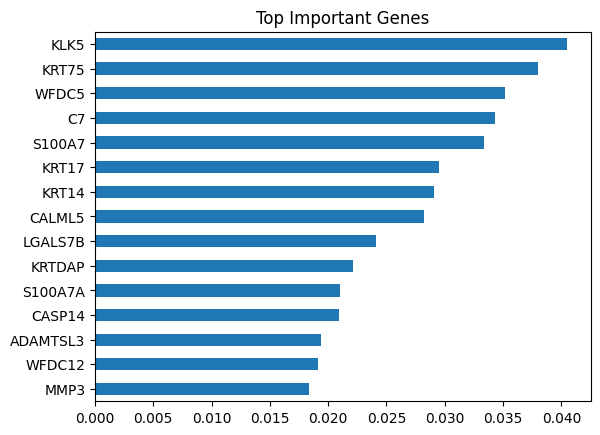

In [14]:
import matplotlib.pyplot as plt

top_genes.plot(kind='barh')
plt.title("Top Important Genes")
plt.gca().invert_yaxis()
plt.show()

In [15]:
import pandas as pd


In [16]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
top_genes = feature_importances.sort_values(ascending=False).head(50)

top_genes.to_csv("top_genes_rf.csv")